<a href="https://colab.research.google.com/github/ctr/medical-physics-demos-2026-03/blob/ctr28%2Fmake_b1plus_demo/tutorials/01_basic_sequences/notebooks/FID_for_slides_mz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Example FID
for the Ph.D. Training program of the German Chapter of the ISMRM

https://github.com/pulseq/MR-Physics-with-Pulseq/tree/main/tutorials/01_basic_sequences/notebooks

In [2]:
!pip show pypulseq || pip install pypulseq==1.4.2.post1 MRzeroCore==0.4.6 sigpy==0.1.27
!wget https://raw.githubusercontent.com/pulseq/MR-Physics-with-Pulseq/main/utils/utils.py > /dev/null 2>&1

  Using cached pypulseq-1.4.2.post1-py3-none-any.whl.metadata (46 kB)
  Using cached mrzerocore-0.4.6-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.9/381.9 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.7/108.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.1/254.1 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.0/475.0 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 17.5 MB/s eta 0:00:00


In [3]:
import math
import warnings
import numpy as np
from matplotlib import pyplot as plt
import pypulseq as mr
import utils # several helper functions for simulation and recon

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
# define high level parameters

fov=256e-3
dwell=10e-5
Nread=64
Nphase=1
TE=5e-3
TR=60e-3

# SETUP
# Set system limits
system = mr.Opts(
    max_grad=32,
    grad_unit="mT/m",
    max_slew=130,
    slew_unit="T/m/s",
    rf_ringdown_time=30e-6,
    rf_dead_time=100e-6,
)

# Create 90 degree slice selection pulse and gradient
rf_ex, gz1, _ = mr.make_sinc_pulse(
    flip_angle=90 * np.pi / 180,
    system=system,
    duration=1e-3,
    slice_thickness=5e-3,
    apodization=0.5,
    time_bw_product=4,
    phase_offset=0* np.pi / 180,
    return_gz=True,
)


print(f"""The bandwidth is {1/dwell:.2f} Hz
and {1/(dwell*Nread):.2f} Hz/px for the {Nread*dwell*1000:.2f} ms ADC.""")

adc = mr.make_adc(
    num_samples=Nread,
    duration=Nread*dwell,
    phase_offset=0* np.pi / 180,
    system=system,)


The bandwidth is 10000.00 Hz
and 156.25 Hz/px for the 6.40 ms ADC.


/tmp/ipykernel_343/3797646579.py:22: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf_ex, gz1, _ = mr.make_sinc_pulse(


In [5]:
# CONSTRUCT SEQUENCE
# Create a new sequence object
seq = mr.Sequence(system)
seq.add_block(rf_ex)
seq.add_block(adc)

In [6]:
# check sequence timing
(ok, error_report) = seq.check_timing()  # Check whether the timing of the sequence is correct
if ok:
    print("Timing check passed successfully")
else:
    print("Timing check failed. Error listing follows:")
    [print(e) for e in error_report]

Timing check passed successfully


#Visualization and Export

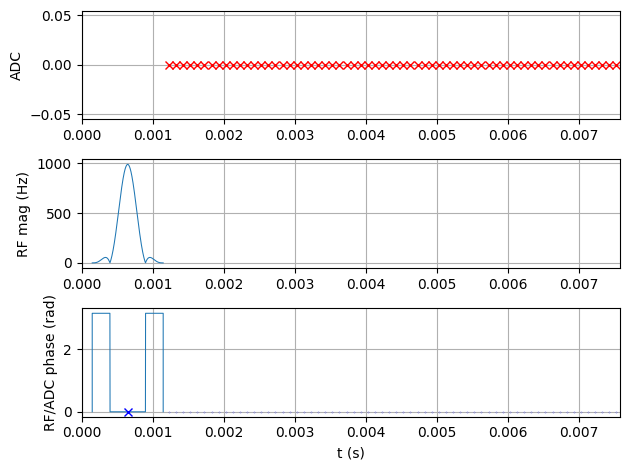

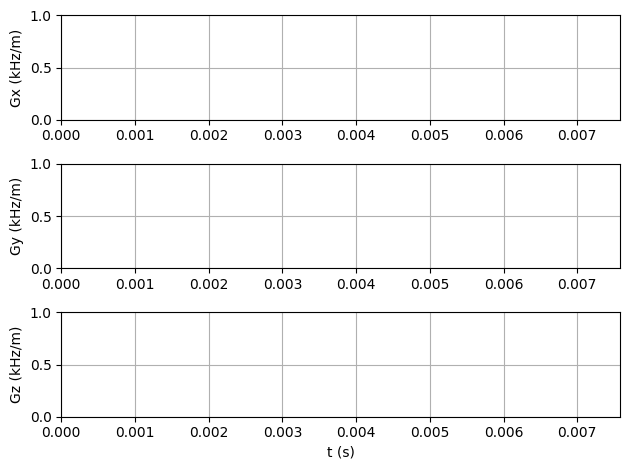

zoom in


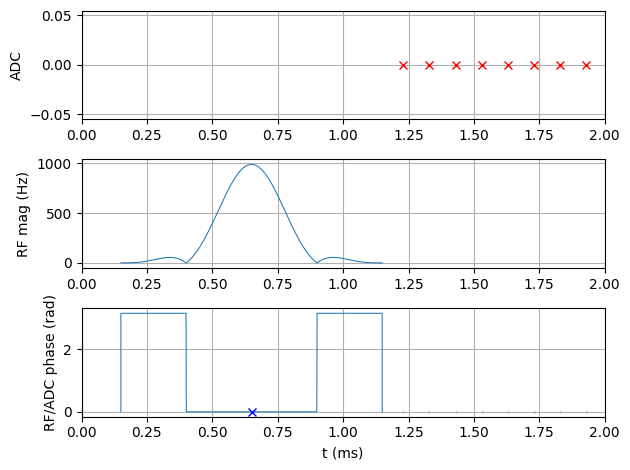

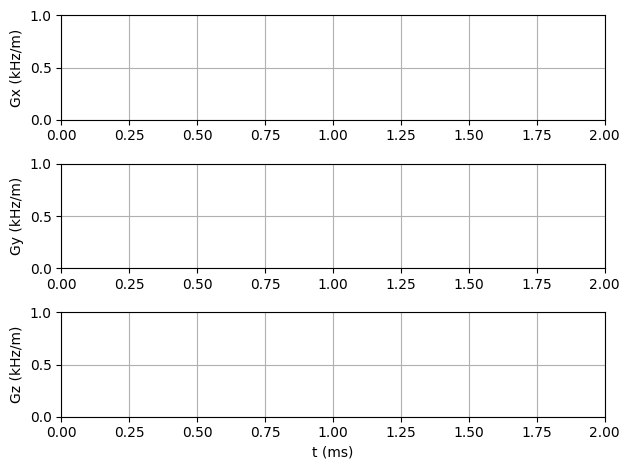

In [7]:
#@title plot sequence
# plot the entire sequence
seq.plot()


# plot just a small initial part
print('zoom in')
seq.plot(time_range=[0, 0.002], time_disp="ms") #


In [8]:
#@title write seq file and export
seq_filename='FID.seq'
seq.write(seq_filename)
from google.colab import files
files.download(seq_filename)  # Download locally

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Simulation

In [9]:
#@title simulation setup
!pip install MRzeroCore &> /dev/null
!wget https://github.com/MRsources/MRzero-Core/raw/main/documentation/playground_mr0/numerical_brain_cropped.mat &> /dev/null
import MRzeroCore as mr0
import importlib
importlib.reload(utils) # Reload utils to recognize MRzeroCore

<module 'utils' from '/content/utils.py'>

Calculating repetition 1 / 1 - done


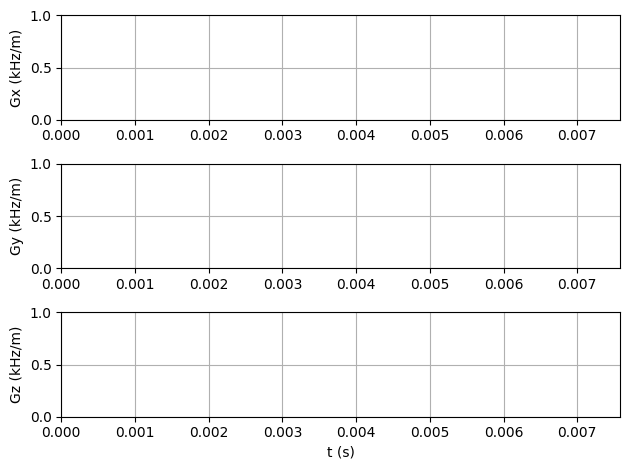

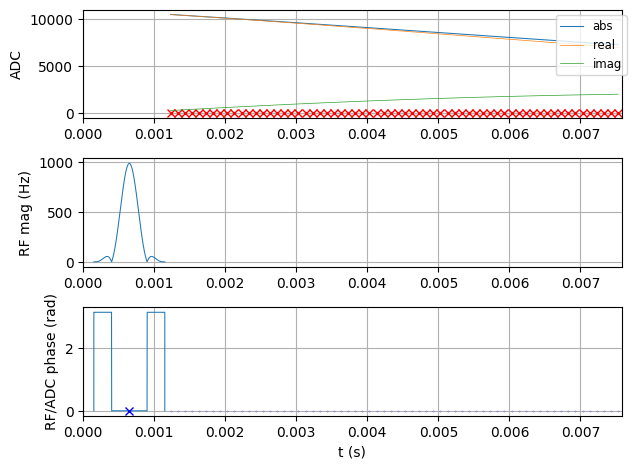

In [10]:
#@title simulation (simple)
# kscape_adc.shape is [N_coils, N_meas, N_adc]
kspace_adc=utils.simulate_2d(seq, noise_level=0, n_coils=1, dB0=+10, B0_scale=1, B0_polynomial=None)
#sp_adc, t_adc = util.pulseq_plot(seq,signal=kspace_adc) # for pypulseq below dev branch.
seq.plot(plot_now=False)
mr0.util.insert_signal_plot(seq, kspace_adc)
plt.show()


VoxelGridPhantom
size = tensor([0.2000, 0.2000, 0.0080])


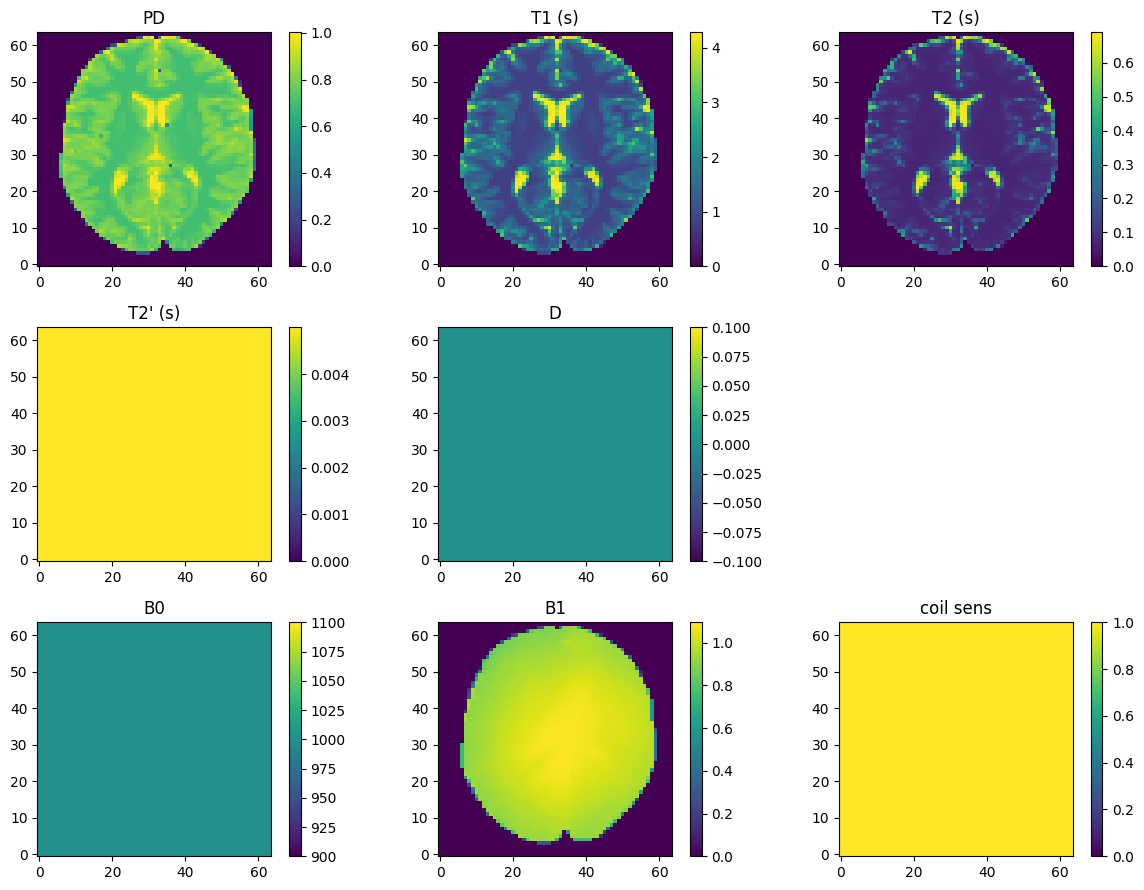

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2012: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.style_literal  = oneOf(
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2024: PyparsingDeprecationWarning: 'oneO

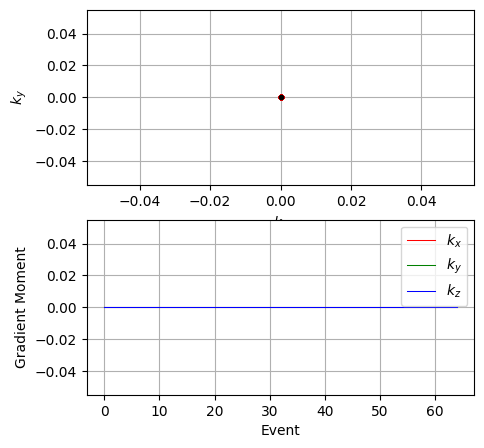

Calculating repetition 1 / 1 - done


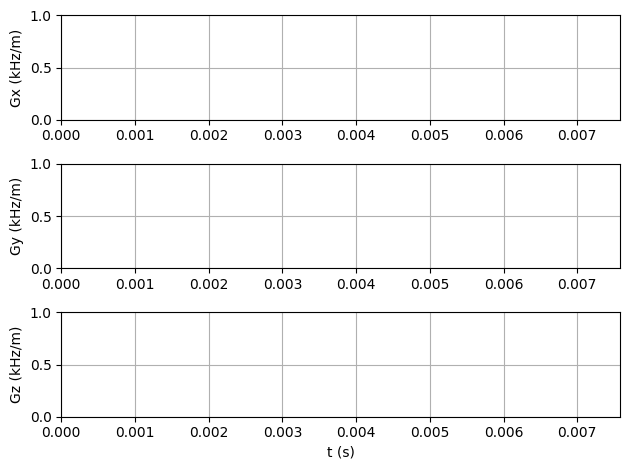

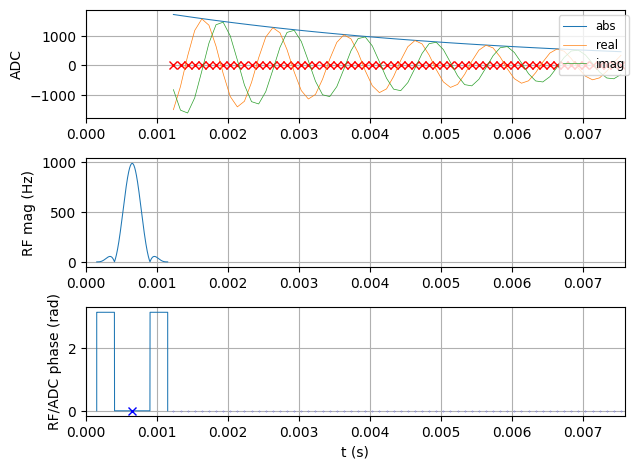

In [11]:
#@title simulation (advanced)
# %% S4: SETUP SPIN SYSTEM/object on which we can run the seq seq_filename
sz = [64, 64]

# (i) load a phantom object from file
obj_p = mr0.VoxelGridPhantom.load_mat('numerical_brain_cropped.mat')
obj_p = obj_p.interpolate(sz[0], sz[1], 1)
# Manipulate loaded data
obj_p.T2dash[:] = 5e-3
obj_p.D *= 0
obj_p.B0 = obj_p.B0*0+1000    # alter the B0 inhomogeneity
# Store PD for comparison
PD = obj_p.PD
B0 = obj_p.B0

obj_p.plot()
# Convert Phantom into simulation data
obj_p = obj_p.build()


# %% S5:. SIMULATE  the external.seq file and add acquired signal to ADC plot

# Read in the sequence
seq0 = mr0.Sequence.import_file(seq_filename)
seq0.plot_kspace_trajectory()
# Simulate the sequence
graph = mr0.compute_graph(seq0, obj_p, max_state_count=1000, min_state_mag=1e-5)
signal = mr0.execute_graph(graph, seq0, obj_p)

# PLOT sequence with signal in the ADC subplot
#sp_adc, t_adc = util.pulseq_plot(seq,signal=kspace_adc) # for pypulseq below dev branch.
seq.plot(plot_now=False)
mr0.util.insert_signal_plot(seq, signal)
plt.show()